In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('alzheimers_disease_data.csv')

print(df.shape)
print(df.head())


(2149, 35)
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientatio

In [66]:
df.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True) #feature engineering 

In [71]:
continuous_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

binary_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints',
    'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

target = 'Diagnosis'

In [67]:
print(df.info())
print(df.describe())
print(df.nunique())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [68]:
print(df.info())
print(df.describe())
print(df.nunique())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

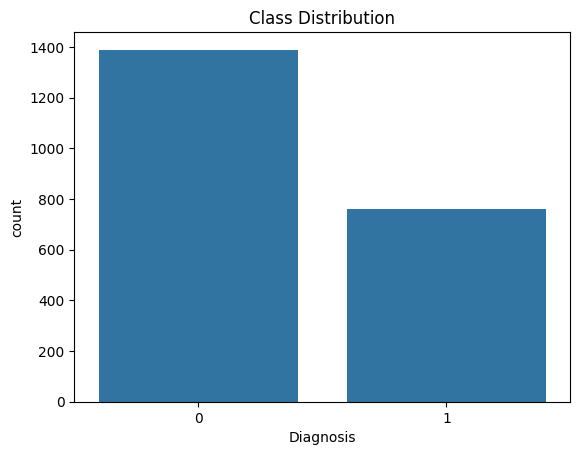

Diagnosis
0    1389
1     760
Name: count, dtype: int64

In [69]:
sns.countplot(x='Diagnosis', data=df)
plt.title('Class Distribution')
plt.show()
df['Diagnosis'].value_counts()

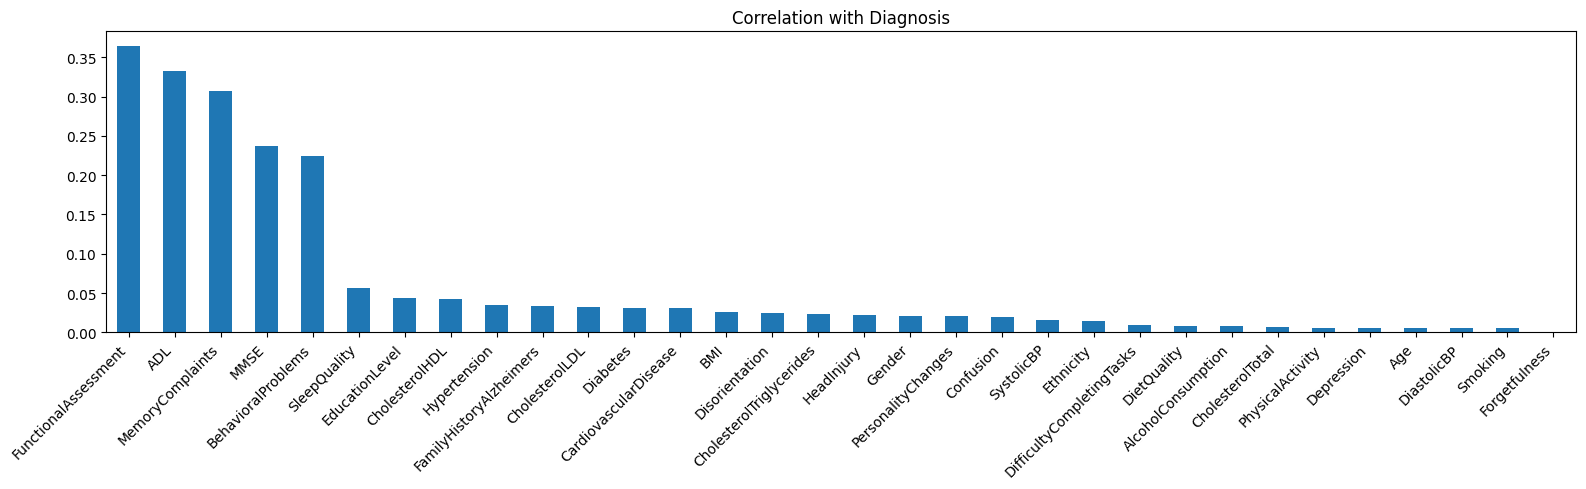

In [72]:
# 2. Correlation with Target
corr = df.corr()['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False)
corr.plot(kind='bar', figsize=(16, 5))
plt.title('Correlation with Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

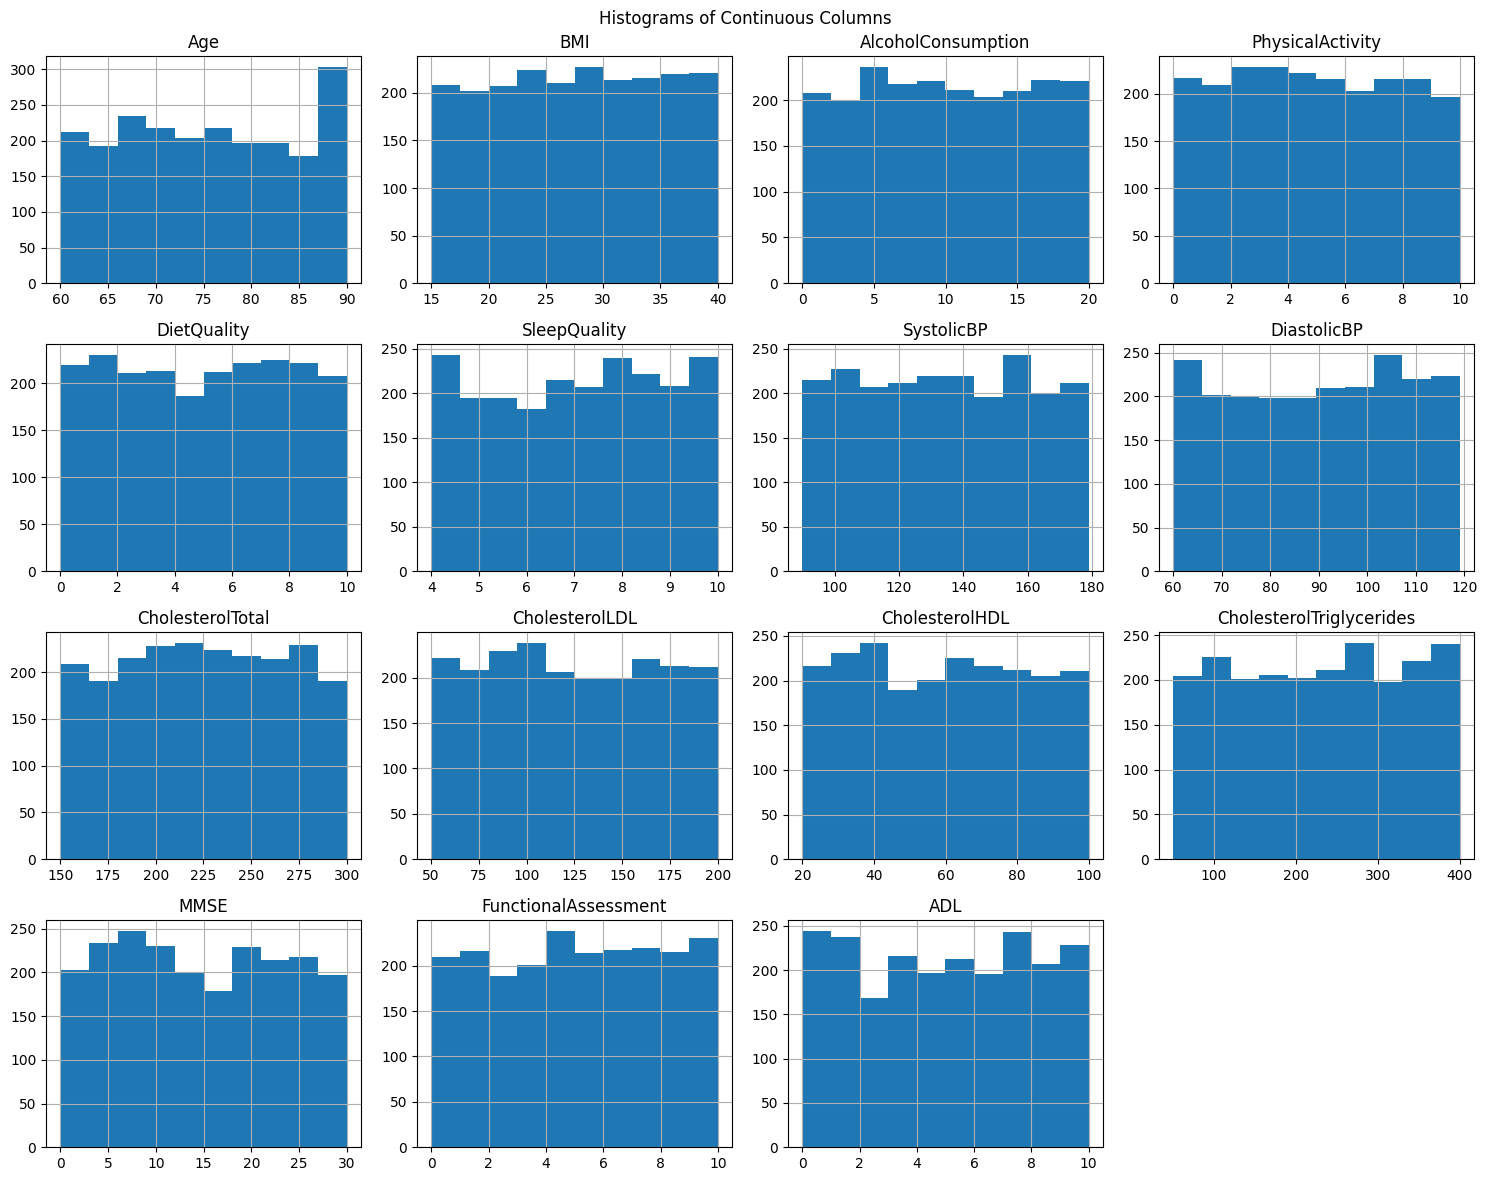

In [73]:
# 3. Histograms
df[continuous_cols].hist(figsize=(15, 12))
plt.suptitle('Histograms of Continuous Columns')
plt.tight_layout()
plt.show()

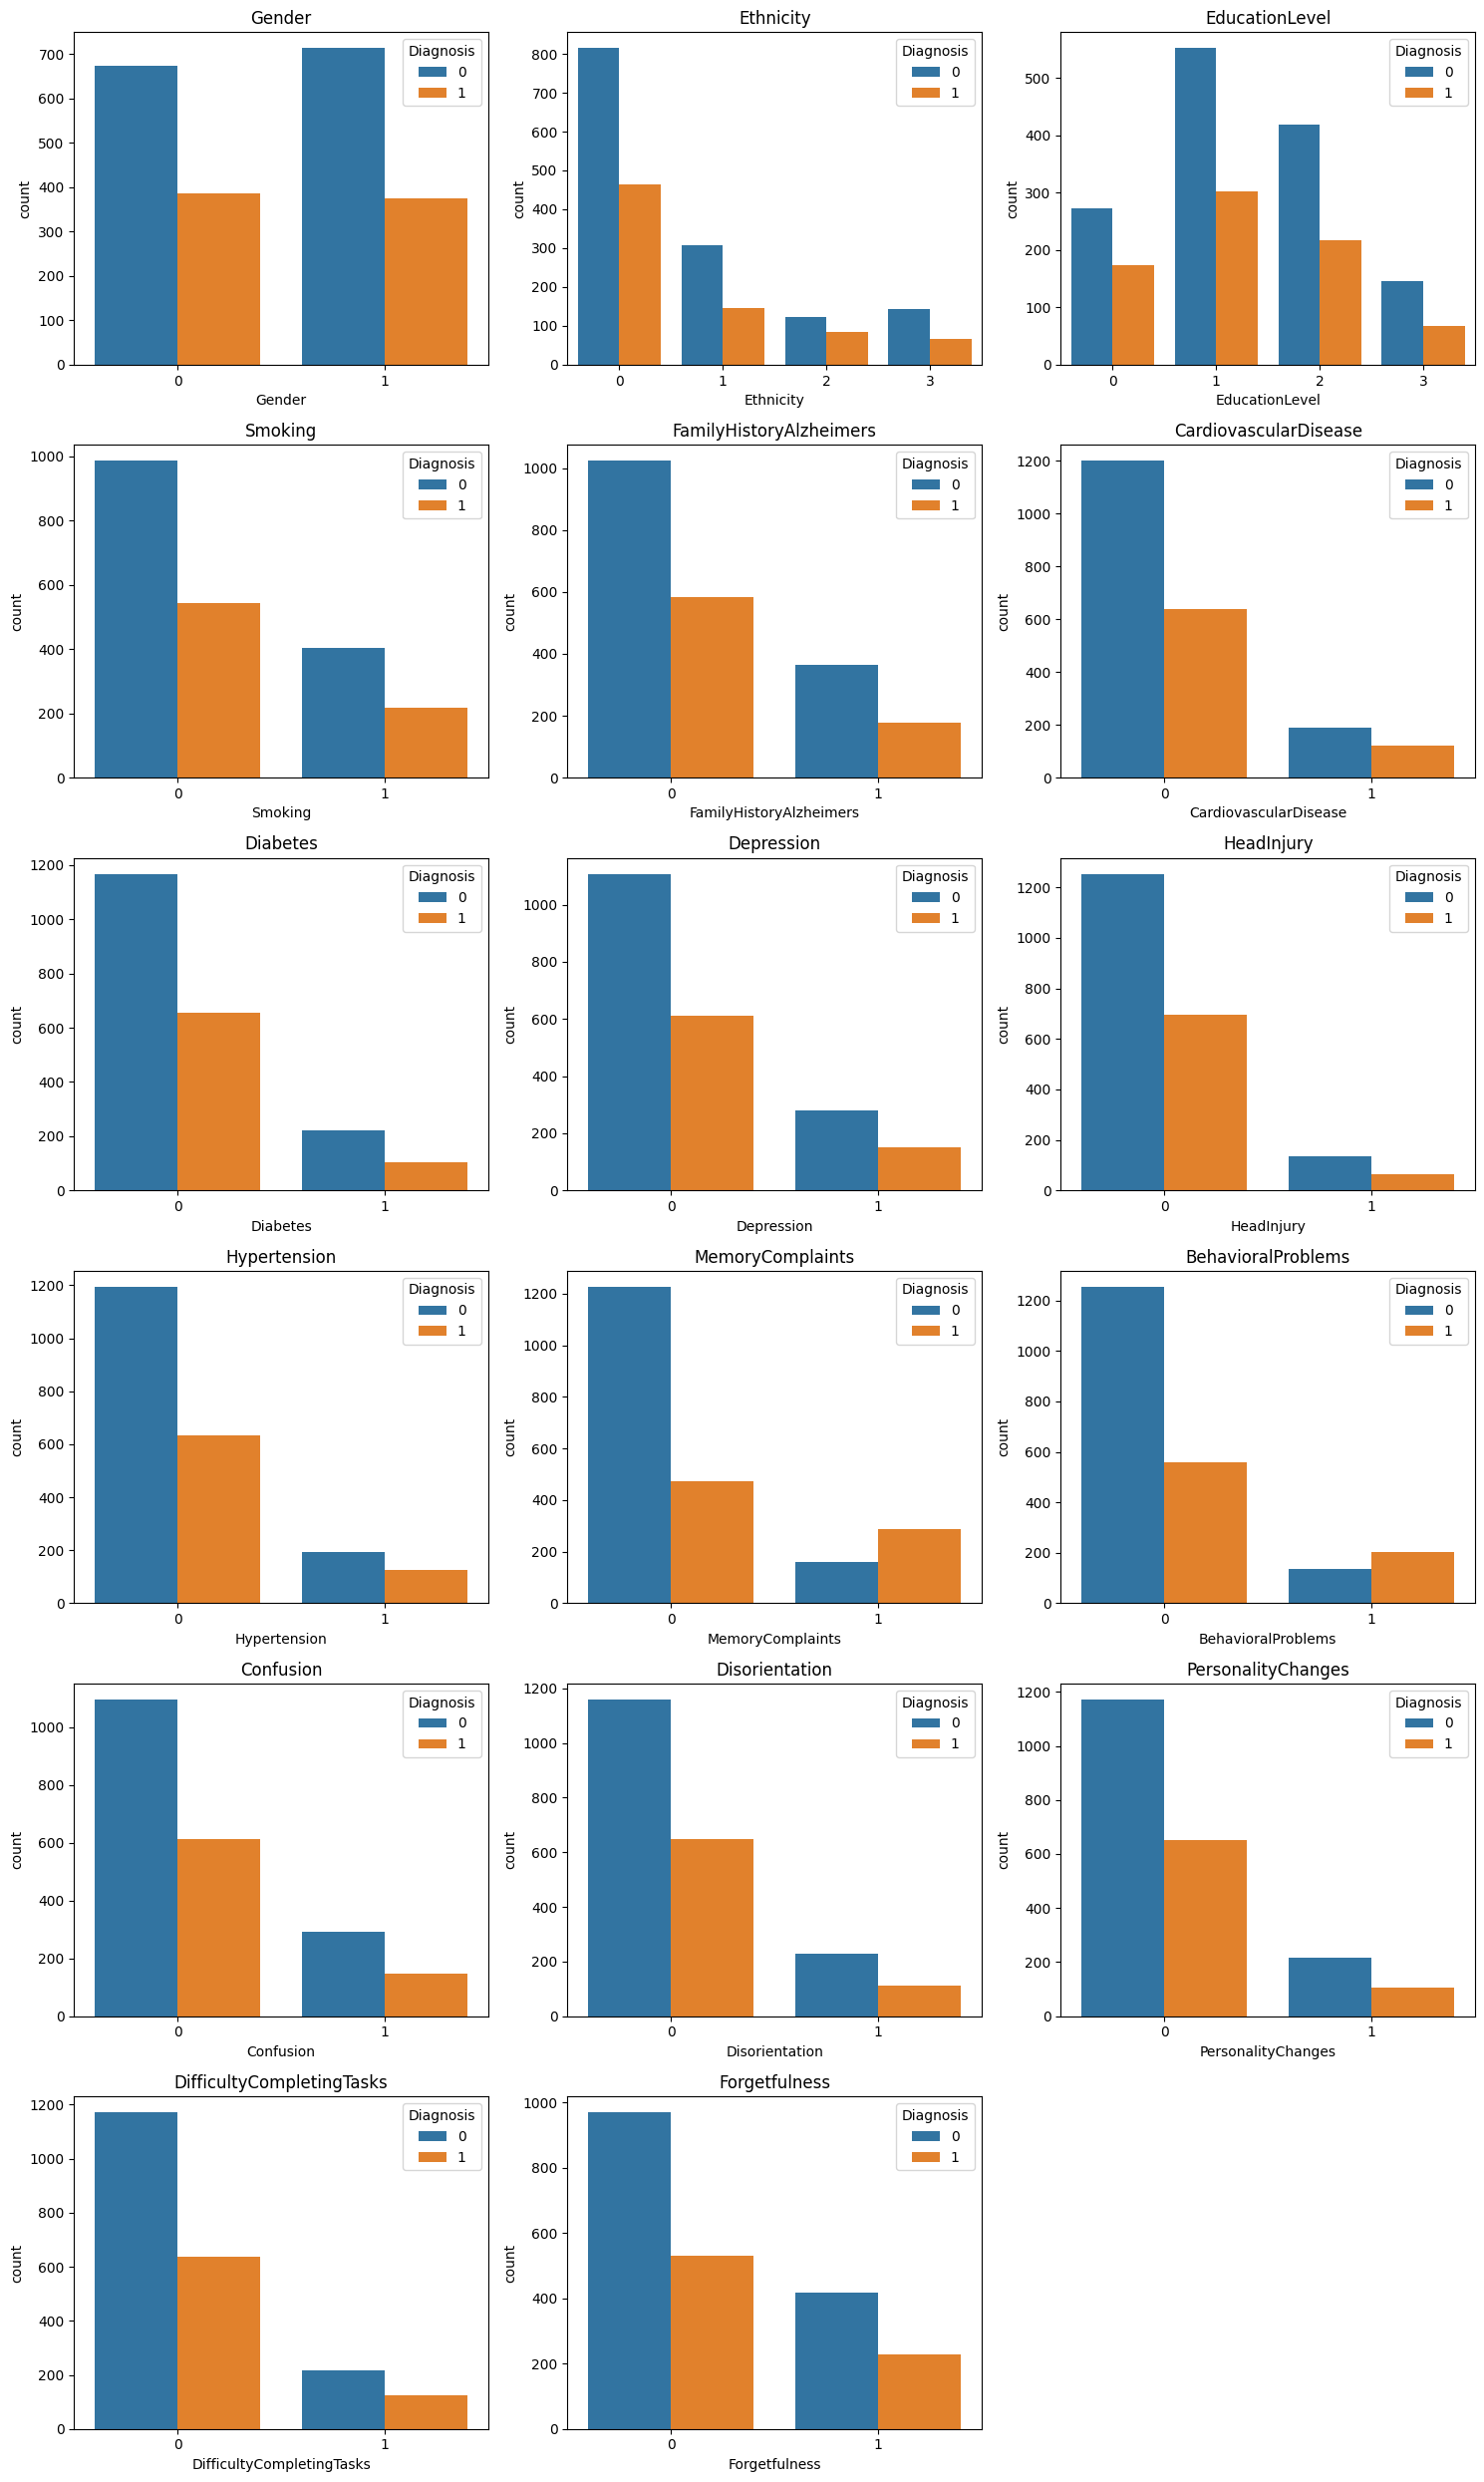

In [74]:
# 4. Count Plots
fig, axes = plt.subplots(6, 3, figsize=(15,25))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='Diagnosis', data=df, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

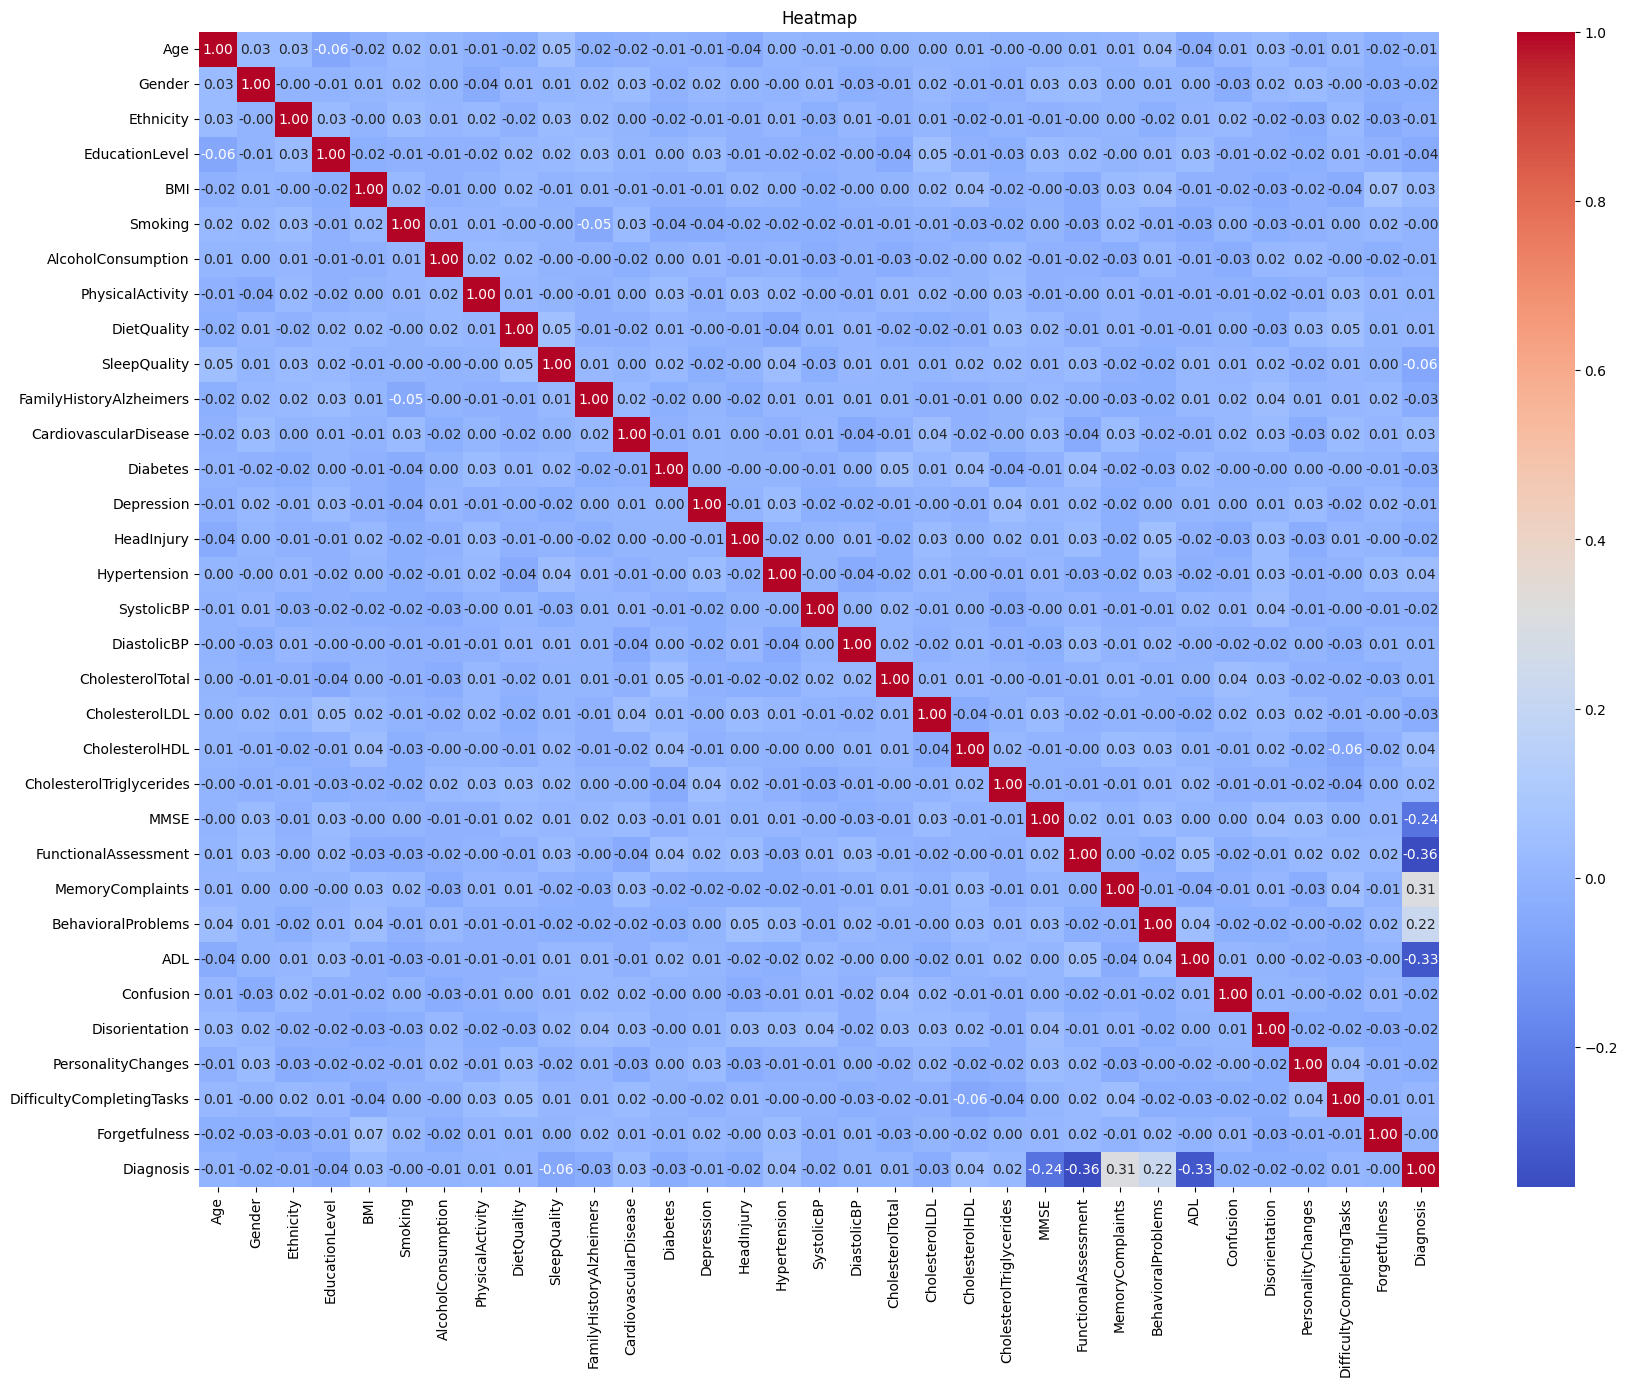

In [75]:
# 5. Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap')
plt.show()

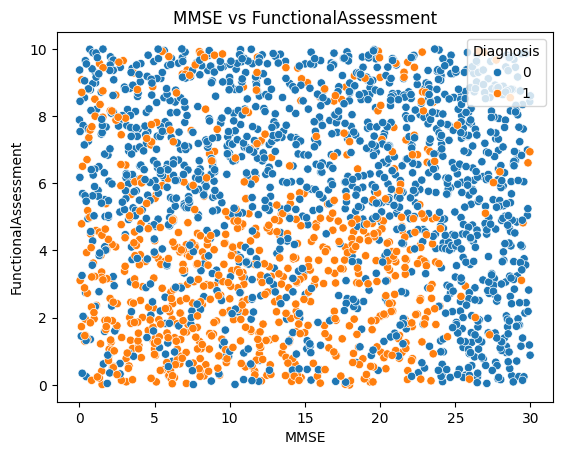

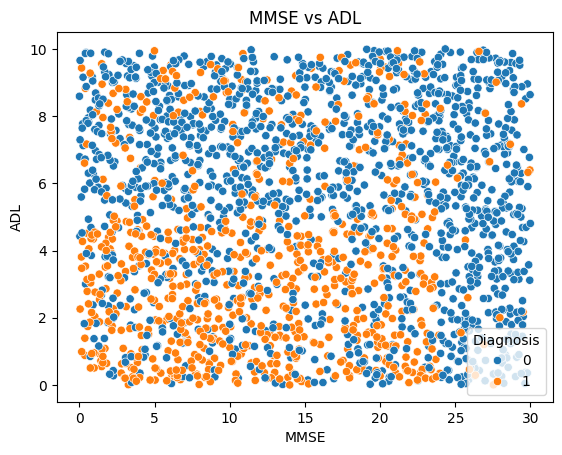

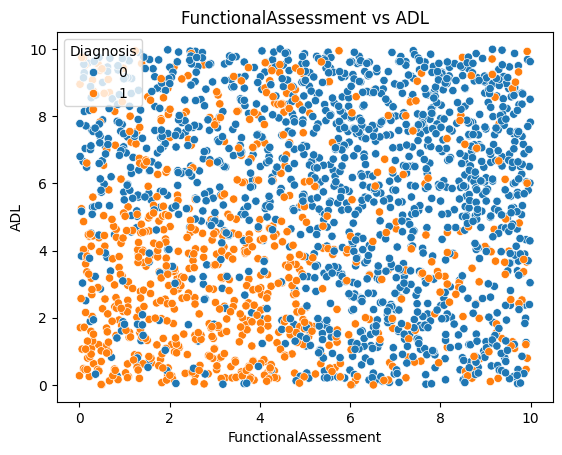

In [76]:
# 6.scatterplot
# MMSE vs FunctionalAssessment
sns.scatterplot(x='MMSE', y='FunctionalAssessment', hue='Diagnosis', data=df)
plt.title('MMSE vs FunctionalAssessment')
plt.show()

# MMSE vs ADL
sns.scatterplot(x='MMSE', y='ADL', hue='Diagnosis', data=df)
plt.title('MMSE vs ADL')
plt.show()

# FunctionalAssessment vs ADL
sns.scatterplot(x='FunctionalAssessment', y='ADL', hue='Diagnosis', data=df)
plt.title('FunctionalAssessment vs ADL')
plt.show()


Age: 0
BMI: 0
AlcoholConsumption: 0
PhysicalActivity: 0
DietQuality: 0
SleepQuality: 0
SystolicBP: 0
DiastolicBP: 0
CholesterolTotal: 0
CholesterolLDL: 0
CholesterolHDL: 0
CholesterolTriglycerides: 0
MMSE: 0
FunctionalAssessment: 0
ADL: 0


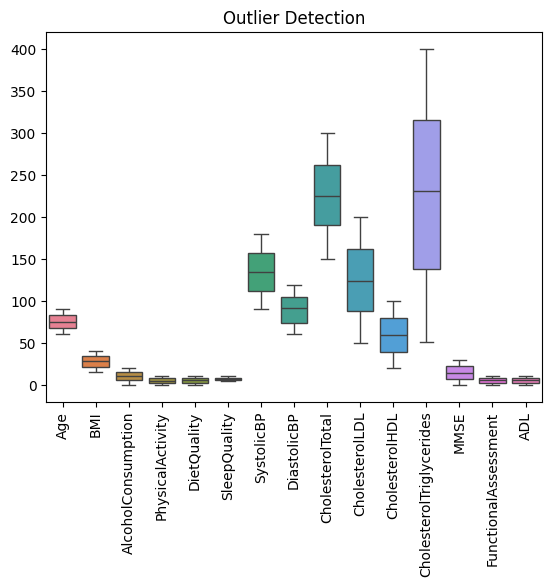

In [77]:
# 6. Outlier Detection
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'{col}: {count}')

sns.boxplot(data=df[continuous_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [78]:

print("WEEK 1 EDA SUMMARY - ALZHEIMER'S DISEASE")

print("\n1. DATASET OVERVIEW")
print("Total patients:", df.shape[0])
print("Total columns:", df.shape[1])
print("Null values:", df.isnull().sum().sum())
print("Dataset is synthetically generated - zero nulls and zero outliers")

print("\n2. CLASS BALANCE")
print(df['Diagnosis'].value_counts())
print("Healthy: 64.6% | Alzheimer's: 35.4%")
print("Dataset is moderately imbalanced")

print("\n3. HISTOGRAM FINDINGS")
print("All continuous columns show uniform distribution")
print("Age ranges from 60 to 90 - elderly patient dataset")
print("No skewness found in any column")

print("\n4. CORRELATION FINDINGS")
print("Top 5 features correlated with Diagnosis:")
print("FunctionalAssessment: 0.36")
print("ADL: 0.33")
print("MemoryComplaints: 0.31")
print("MMSE: 0.24")
print("BehavioralProblems: 0.22")
print("All remaining features below 0.06 - weak predictors")

print("\n5. BOX PLOT FINDINGS")
print("Strong predictors: FunctionalAssessment, ADL, MMSE")
print("All other continuous columns show heavy overlap")

print("\n6. COUNT PLOT FINDINGS")
print("Strong binary predictors: MemoryComplaints, BehavioralProblems")
print("Weak binary predictors: Gender, Smoking, Diabetes")

print("\n7. HEATMAP FINDINGS")
print("No multicollinearity found between features")
print("All inter-feature correlations near zero")

print("\n8. OVERALL CONCLUSION")
print("Top 5 features for modeling:")
print("FunctionalAssessment, ADL, MMSE, MemoryComplaints, BehavioralProblems")
print("These will be most important in Week 2 modeling")

WEEK 1 EDA SUMMARY - ALZHEIMER'S DISEASE

1. DATASET OVERVIEW
Total patients: 2149
Total columns: 33
Null values: 0
Dataset is synthetically generated - zero nulls and zero outliers

2. CLASS BALANCE
Diagnosis
0    1389
1     760
Name: count, dtype: int64
Healthy: 64.6% | Alzheimer's: 35.4%
Dataset is moderately imbalanced

3. HISTOGRAM FINDINGS
All continuous columns show uniform distribution
Age ranges from 60 to 90 - elderly patient dataset
No skewness found in any column

4. CORRELATION FINDINGS
Top 5 features correlated with Diagnosis:
FunctionalAssessment: 0.36
ADL: 0.33
MemoryComplaints: 0.31
MMSE: 0.24
BehavioralProblems: 0.22
All remaining features below 0.06 - weak predictors

5. BOX PLOT FINDINGS
Strong predictors: FunctionalAssessment, ADL, MMSE
All other continuous columns show heavy overlap

6. COUNT PLOT FINDINGS
Strong binary predictors: MemoryComplaints, BehavioralProblems
Weak binary predictors: Gender, Smoking, Diabetes

7. HEATMAP FINDINGS
No multicollinearity found